# RasterIO 
## A brief intro to a *pythonic* raster library

In order to run this notebook, please do what follows:

    cd  /media/sf_LVM_shared/my_SE_data/exercise
    jupyter-notebook RasterIO_Intro.ipynb

---


**RasterIO** is a library that simplifies the use of the raster swiss-knife geospatial library (**GDAL**) from Python (... and talking about that, [how do you pronounce GDAL?](https://soundcloud.com/danabauer/how-do-you-pronounce-gdal)).

Ratio: GDAL is C++ library with a public C interface for other languages bindings, therefore its Python API is quite rough from the mean Python programmer's point of view (i.e. it is not *pythonic* enough). RasterIO is for rasters what Fiona is for vectors.

*Note: [`Open Source Approaches in Spatial Data Handling`](https://link.springer.com/book/10.1007/978-3-540-74831-1) is a good comprehensive book about the history and roles of FOSS in the geospatial domain.*


## Rasterio basics

In [2]:
import rasterio # that's to use it

In [3]:
rasterio.__version__

'1.3.2'

In [38]:
dataset = rasterio.open('geodata/dem/SA_elevation_mn_GMTED2010_mn_msk.tif', mode='r') # r+ w w+ r

A lots of different parameters can be specified, including all GDAL valid open() attributes. Most of the parameters make sense in write mode to create a new raster file:
* dtype
* nodata
* crs
* width, height
* transform
* count
* driver

More information are available in the API reference documentation [here](https://rasterio.readthedocs.io/en/stable/api/rasterio.html#rasterio.open). Note that in some specific cases you will need to preceed a regular `open()` with `rasterio.Env()` to customize `GDAL` for your uses (e.g. caching, color tables, driver options, etc.).

Note that the filename in general can be any valid URL and even a dataset within some container file (e.g. a variable in Netcdf or HDF5 file). Even object storage (e.g AWS S3) and zip URLs can be considered.

Let's see a series of simple methods that can be used to access metadata and pixel values

In [39]:
dataset

<open DatasetReader name='geodata/dem/SA_elevation_mn_GMTED2010_mn_msk.tif' mode='r'>

In [40]:
dataset.name

'geodata/dem/SA_elevation_mn_GMTED2010_mn_msk.tif'

In [41]:
dataset.mode # read-only?

'r'

In [42]:
dataset.closed # bis still open? you gess what the meaning of dataset.close()

False

In [43]:
dataset.count

1

In [44]:
dataset.bounds

BoundingBox(left=-83.0, bottom=-56.0, right=-34.0, top=14.0)

In [45]:
dataset.transform

Affine(0.008333333333333333, 0.0, -83.0,
       0.0, -0.008333333333333333, 14.0)

In [46]:
dataset.transform * (0,0)

(-83.0, 14.0)

In [47]:
dataset.transform * (dataset.width-1, dataset.height-1)

(-34.00833333333333, -55.99166666666666)

In [48]:
dataset.index(9.99975, 47.90025) # use geographical coords, by long and lat and gives (row,col)

(-4069, 11159)

In [49]:
dataset.xy(8399, 15999) # give geometric coords long and lat, by row and col !

(50.32916666666665, -55.99583333333334)

In [50]:
dataset.crs

CRS.from_epsg(4326)

In [51]:
dataset.shape

(8400, 5880)

In [52]:
dataset.meta

{'driver': 'GTiff',
 'dtype': 'int16',
 'nodata': -9999.0,
 'width': 5880,
 'height': 8400,
 'count': 1,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.008333333333333333, 0.0, -83.0,
        0.0, -0.008333333333333333, 14.0)}

In [53]:
dataset.dtypes

('int16',)

Raster bands can be loaded as a whole thanks to **numpy** 

In [54]:
dataset.indexes

(1,)

In [55]:
band = dataset.read(1) # loads the first band in a numpy array

In [56]:
band

array([[-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       ...,
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999],
       [-9999, -9999, -9999, ..., -9999, -9999, -9999]], dtype=int16)

In [57]:
band[0,0]

-9999

In [58]:
band[4440,1555] # access by row,col as a matrix

1325

In [59]:
dataset.width, dataset.height

(5880, 8400)

In [60]:
band[949,1549]

95

Rasterio includes also some utility methods to show raster data, using `matplotlib` under the hood.

In [61]:
import rasterio.plot

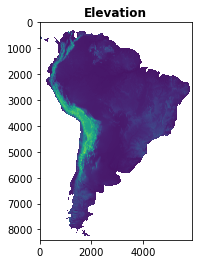

<AxesSubplot:title={'center':'Elevation'}>

In [67]:
rasterio.plot.show(band, title='Elevation')

In [63]:
rasterio.plot.plotting_extent(dataset)

(-83.0, -34.0, -56.0, 14.0)

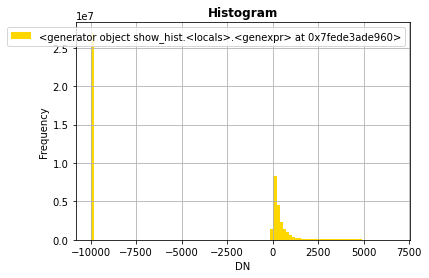

In [64]:
rasterio.plot.show_hist(band, bins=100)

Note that you need to explicity filter out nodata values at read time.

In [65]:
band = dataset.read(masked=True)
band

masked_array(
  data=[[[--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         ...,
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --],
         [--, --, --, ..., --, --, --]]],
  mask=[[[ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         ...,
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True],
         [ True,  True,  True, ...,  True,  True,  True]]],
  fill_value=-9999,
  dtype=int16)

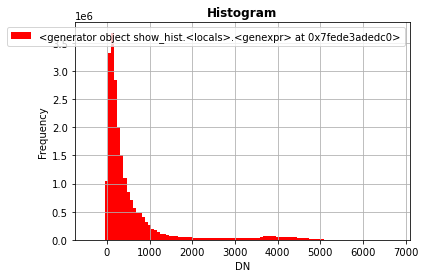

In [66]:
rasterio.plot.show_hist(band, bins=100)

The mask operation is also efection the plot layout.

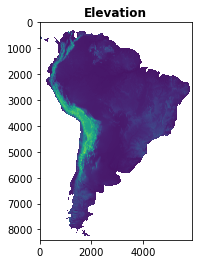

<AxesSubplot:title={'center':'Elevation'}>

In [68]:
rasterio.plot.show(band, title='Elevation')

Alternatively (e.g. when raster missing nodata definition, which in practice happens quite often :-)) you need to explicitly mask on your own the input data.

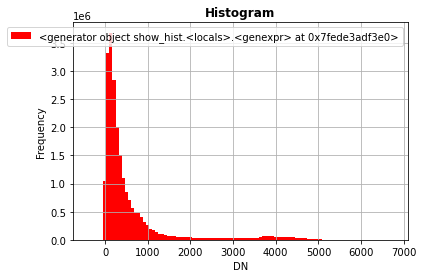

In [69]:
import numpy as np

band = dataset.read()
band_masked = np.ma.masked_array(band, mask=(band == -9999.0)) # mask whatever required
band_masked
rasterio.plot.show_hist(band_masked, bins=100)

The `rasterio` can package can also read directly multi-bands images. 

In [103]:
multi = rasterio.open('geodata/glad_ard/942_crop.tif', mode='r')

In [71]:
m = multi.read()
m.shape

(8, 440, 400)

Note that rasterio uses bands/rows/cols order in managing images, which is not the same of other packages!

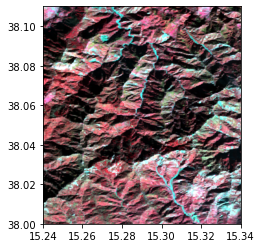

In [93]:
def pct_clip(array,pct=[2,98]):
    array_min, array_max = np.nanpercentile(array,pct[0]), np.nanpercentile(array,pct[1])
    clip = (array - array_min) / (array_max - array_min)
    clip[clip>1]=1
    clip[clip<0]=0
    return clip

with rasterio.open("geodata/glad_ard/942_crop.tif") as src:
    with rasterio.open(
            '942_crop.tif', 'w+',
            driver='GTiff',
            dtype= rasterio.float32,
            count=3,
            crs = src.crs,
            width=src.width,
            height=src.height,
            transform=src.transform,
        ) as dst:
        V = pct_clip(src.read(4))
        dst.write(V,1)
        V = pct_clip(src.read(3))
        dst.write(V,2)
        V = pct_clip(src.read(2))
        dst.write(V,3)
    
fig,ax=plt.subplots()
with rasterio.open("942_crop.tif") as src2:
    rasterio.plot.show(src2.read(),transform=src2.transform,ax=ax)

## 1.2 An example of computation: NDVI

The real computation via `numpy` arrays

In [105]:
multi_msk = multi.read(masked=True)
ndvi = (multi_msk[3]-multi_msk[2]) / (multi_msk[3]+multi_msk[2])
ndvi.min(), ndvi.max()

(0.07209653092006033, 0.851783458062008)

In [106]:
multi.shape

(440, 400)

In order to write the result all metainfo must be prepared, the easiest way is by using the input ones.

In [107]:
multi.profile

{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 400, 'height': 440, 'count': 8, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.00025, 0.0, 15.24,
       0.0, -0.00025, 38.11), 'tiled': False, 'compress': 'deflate', 'interleave': 'pixel'}

In [108]:
profile = multi.profile
profile.update(dtype=rasterio.float32, count=1, driver='GTiff')
profile

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 400, 'height': 440, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.00025, 0.0, 15.24,
       0.0, -0.00025, 38.11), 'tiled': False, 'compress': 'deflate', 'interleave': 'pixel'}

In [109]:
with rasterio.open('geodata/glad_ard/942_crop_ndvi.tif', mode='w', **profile) as out:
    out.write(ndvi.astype(rasterio.float32), 1)

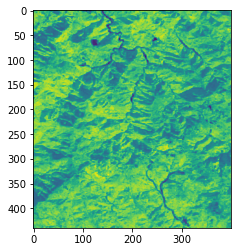

<AxesSubplot:>

In [110]:
rasterio.plot.show(ndvi)

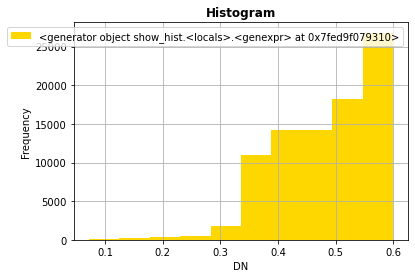

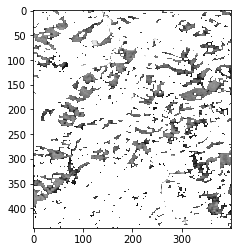

<AxesSubplot:>

In [111]:
import numpy as np

urb = np.ma.masked_array(ndvi, mask=(ndvi >= 0.6))
rasterio.plot.show_hist(urb)
rasterio.plot.show(urb,cmap='Greys')

In [112]:
ndvi_stats = [ndvi.min(), ndvi.mean(), np.ma.median(ndvi), ndvi.max(), ndvi.std()]
ndvi_stats

[0.07209653092006033,
 0.579103729330517,
 0.6012272128758722,
 0.851783458062008,
 0.11555229471805274]

In [113]:
urb_stats = [urb.min(), urb.mean(), np.ma.median(urb), urb.max(), urb.std()]
urb_stats

[0.07209653092006033,
 0.48462524261699785,
 0.49912903658046365,
 0.5999793856936714,
 0.08450404687909031]

It is possibile to use a vector model for masking in rasterio, let's see how.
First of all, we are creating a `GeoJSON` vector.

In [137]:
%%bash

cat >/tmp/clip.json <<EOF
{
"type": "FeatureCollection",
"name": "clip",
"crs": { "type": "name", "properties": { "name": "urn:ogc:def:crs:EPSG::32119" } },
"features": [
{ "type": "Feature", "properties": { "id": null }, "geometry": { "type": "Polygon", "coordinates": [ [ [15.24, 38.09 ], [ 15.32, 38.09 ], [15.32, 38.00], [15.24, 38.00], [15.24, 38.09] ] ] } }
]
}
EOF


In [138]:
! ogrinfo -al /tmp/clip.json

INFO: Open of `/tmp/clip.json'
      using driver `GeoJSON' successful.

Layer name: clip
Geometry: Polygon
Feature Count: 1
Extent: (15.240000, 38.000000) - (15.320000, 38.090000)
Layer SRS WKT:
PROJCRS["NAD83 / North Carolina",
    BASEGEOGCRS["NAD83",
        DATUM["North American Datum 1983",
            ELLIPSOID["GRS 1980",6378137,298.257222101,
                LENGTHUNIT["metre",1]]],
        PRIMEM["Greenwich",0,
            ANGLEUNIT["degree",0.0174532925199433]],
        ID["EPSG",4269]],
    CONVERSION["SPCS83 North Carolina zone (meters)",
        METHOD["Lambert Conic Conformal (2SP)",
            ID["EPSG",9802]],
        PARAMETER["Latitude of false origin",33.75,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8821]],
        PARAMETER["Longitude of false origin",-79,
            ANGLEUNIT["degree",0.0174532925199433],
            ID["EPSG",8822]],
        PARAMETER["Latitude of 1st standard parallel",36.1666666666667,
            ANGLEUNIT["de

In [139]:
import rasterio.mask
import fiona

In [140]:
with fiona.open('/tmp/clip.json', 'r') as geojson:
    shapes = [feature['geometry'] for feature in geojson]
shapes

[{'type': 'Polygon',
  'coordinates': [[(15.24, 38.09),
    (15.32, 38.09),
    (15.32, 38.0),
    (15.24, 38.0),
    (15.24, 38.09)]]}]

In [141]:
clip_image, clip_transform = rasterio.mask.mask(multi, shapes, crop=True) # why transform? ;-)
clip_image.shape

(8, 360, 320)

In [142]:
multi.meta

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 400,
 'height': 440,
 'count': 8,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.00025, 0.0, 15.24,
        0.0, -0.00025, 38.11)}

In [143]:
profile = multi.meta
profile.update({'driver': 'GTiff', 
                'width': clip_image.shape[1], 
                'height': clip_image.shape[2], 
                'transform': clip_transform,
               })
profile

{'driver': 'GTiff',
 'dtype': 'uint16',
 'nodata': None,
 'width': 360,
 'height': 320,
 'count': 8,
 'crs': CRS.from_epsg(4326),
 'transform': Affine(0.00025, 0.0, 15.24,
        0.0, -0.00025, 38.089999999999996)}

In [144]:
dst = rasterio.open('/tmp/clipped.tif', 'w+', **profile)
dst.write(clip_image)

In [145]:
dst.shape

(320, 360)

In [146]:
rst = dst.read(masked=True)
rst.shape

(8, 320, 360)

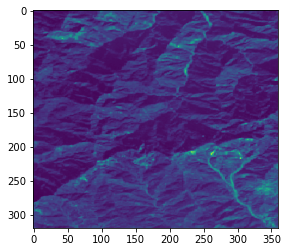

<AxesSubplot:>

In [147]:
rasterio.plot.show(rst[0])

Note that all read/write operation in RasterIO are performed for the whole size of the dataset, so the package is limited (somehow ...) by memory available. An alternative is using *windowing* in read/write operation.

In [148]:
import rasterio.windows

rasterio.windows.Window(0,10,100,100)

Window(col_off=0, row_off=10, width=100, height=100)

In [149]:
win = rasterio.windows.Window(0,10,100,100)
src = rasterio.open('/tmp/clipped.tif', mode='r')
w = src.read(window=win)
w.shape

(8, 100, 100)

Of course if you tile the input source and output sub-windows of results, a new trasform will need to be provided for each tile, and the `window_transform()` method can be used for that.

In [150]:
src.transform

Affine(0.00025, 0.0, 15.24,
       0.0, -0.00025, 38.089999999999996)

In [151]:
src.window_transform(win)

Affine(0.00025, 0.0, 15.24,
       0.0, -0.00025, 38.0875)

Note that in many cases could be convenient aligning to the existing (format related) block size organization of the file, which *should* be the minimal chunck of I/O in GDAL.

In [152]:
for i, shape in enumerate(src.block_shapes, 1):
    print(i, shape)

1 (1, 360)
2 (1, 360)
3 (1, 360)
4 (1, 360)
5 (1, 360)
6 (1, 360)
7 (1, 360)
8 (1, 360)


More information, examples and documentation about `RasterIO` are [here](https://rasterio.readthedocs.io/en/stable/index.html)

 ## 1.3 The rio CLI tool 

RasterIO has also a command line tool (`rio`) which can be used to perform a series of operation on rasters, which complementary in respect with the GDAL tools.If you install rasterio from distribution/kit it will reside in the ordinary system paths (note: you could find a `rasterio` binary instead of `rio`). If you install from the PyPI repository via `pip` it will install under `~/.local/bin`.

In [153]:
! rio --help

Usage: rio [OPTIONS] COMMAND [ARGS]...

  Rasterio command line interface.

Options:
  -v, --verbose           Increase verbosity.
  -q, --quiet             Decrease verbosity.
  --aws-profile TEXT      Select a profile from the AWS credentials file
  --aws-no-sign-requests  Make requests anonymously
  --aws-requester-pays    Requester pays data transfer costs
  --version               Show the version and exit.
  --gdal-version
  --show-versions         Show dependency versions
  --help                  Show this message and exit.

Commands:
  blocks     Write dataset blocks as GeoJSON features.
  bounds     Write bounding boxes to stdout as GeoJSON.
  calc       Raster data calculator.
  clip       Clip a raster to given bounds.
  convert    Copy and convert raster dataset.
  edit-info  Edit dataset metadata.
  env        Print information about the Rasterio environment.
  gcps       Print ground control points as GeoJSON.
  info       Print information about a data file.
  insp     

In [154]:
! rio bounds --indent 1 geodata/dem/SA_elevation_mn_GMTED2010_mn_msk.tif # output a GeoJSON polygon for the bounding box

{
 "bbox": [
  -83.0,
  -56.0,
  -34.0,
  14.0
 ],
 "geometry": {
  "coordinates": [
   [
    [
     -83.0,
     -56.0
    ],
    [
     -34.0,
     -56.0
    ],
    [
     -34.0,
     14.0
    ],
    [
     -83.0,
     14.0
    ],
    [
     -83.0,
     -56.0
    ]
   ]
  ],
  "type": "Polygon"
 },
 "properties": {
  "filename": "SA_elevation_mn_GMTED2010_mn_msk.tif",
  "id": "0",
  "title": "geodata/dem/SA_elevation_mn_GMTED2010_mn_msk.tif"
 },
 "type": "Feature"
}


A quite interesting feature is the raster calculator which uses a Lisp-like language notation, which is the s-expression notation of *Snuggs*, part of `numpy`. Largely undocumented, you need to have a look to the code
[here](https://github.com/mapbox/snuggs/blob/master/snuggs/__init__.py) and its README file :-(

In [155]:
! rio calc "(+ 2.0 (* 0.95 (read 1)))" --overwrite geodata/dem/SA_elevation_mn_GMTED2010_mn_msk.tif /tmp/elev.tif # Lisp like lists :-( 

Simple comuputations can be done via `rio` or written via ad hoc script at your will. 